<a href="https://colab.research.google.com/github/vaishnavi-gujare/Dataframe-projects/blob/main/task_insurance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import files
uploded = (files.upload())

Saving insurance.csv to insurance (2).csv


In [ ]:
df = pd.read_csv("insurance.csv")
df

,age,sex,bmi,children,smoker,region,expenses
0,19,female,27.9,0,yes,southwest,16884.92
1,18,male,33.8,1,no,southeast,1725.55
2,28,male,33.0,3,no,southeast,4449.46
3,33,male,22.7,0,no,northwest,21984.47
4,32,male,28.9,0,no,northwest,3866.86
...,...,...,...,...,...,...,...
1333,50,male,31.0,3,no,northwest,10600.55
1334,18,female,31.9,0,no,northeast,2205.98
1335,18,female,36.9,0,no,southeast,1629.83
1336,21,female,25.8,0,no,southwest,2007.95


In [ ]:
print(df.head())

   age     sex   bmi  children smoker     region  expenses
0   19  female  27.9         0    yes  southwest  16884.92
1   18    male  33.8         1     no  southeast   1725.55
2   28    male  33.0         3     no  southeast   4449.46
3   33    male  22.7         0     no  northwest  21984.47
4   32    male  28.9         0     no  northwest   3866.86


In [ ]:
print(df.shape)

(1338, 7)


In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   expenses  1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None


In [ ]:
print(df.isnull().sum())

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
expenses    0
dtype: int64


In [ ]:
df.duplicated().sum()

np.int64(1)

In [ ]:
df = df.drop_duplicates()

In [ ]:
print(df.describe())

               age          bmi     children      expenses
count  1337.000000  1337.000000  1337.000000   1337.000000
mean     39.222139    30.665520     1.095737  13279.121638
std      14.044333     6.100664     1.205571  12110.359657
min      18.000000    16.000000     0.000000   1121.870000
25%      27.000000    26.300000     0.000000   4746.340000
50%      39.000000    30.400000     1.000000   9386.160000
75%      51.000000    34.700000     2.000000  16657.720000
max      64.000000    53.100000     5.000000  63770.430000


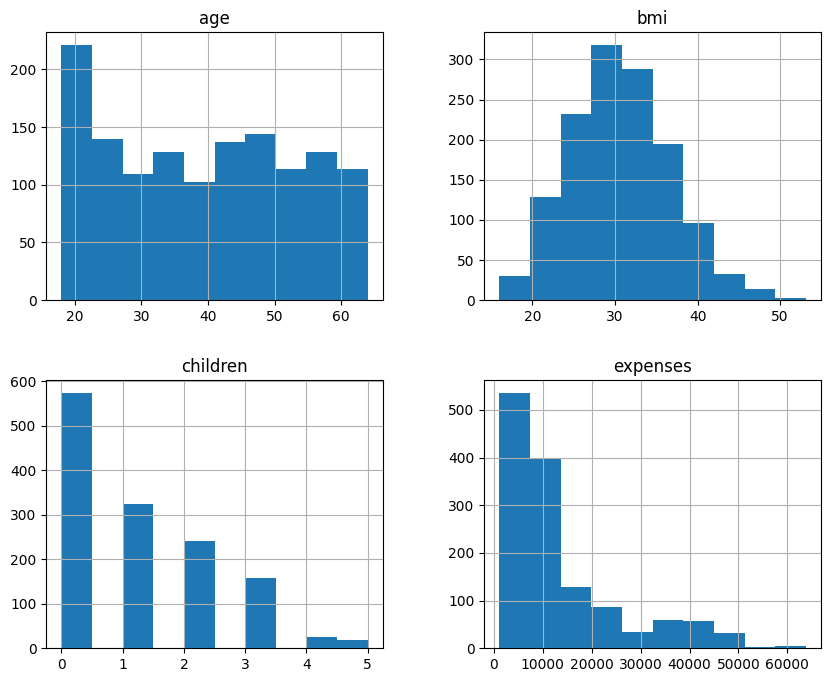

In [ ]:
df.hist(figsize=(10,8))
plt.show()

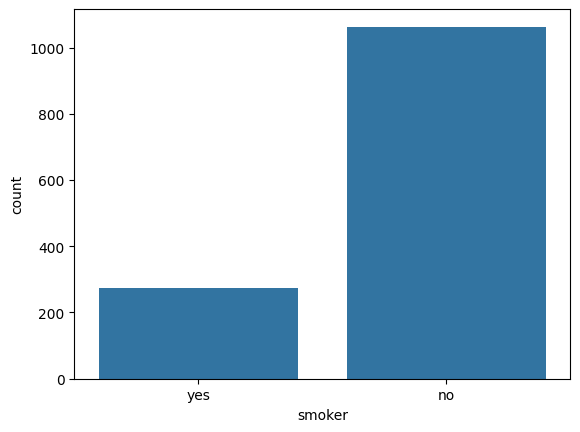

In [ ]:
sns.countplot(x='smoker', data=df)
plt.show()

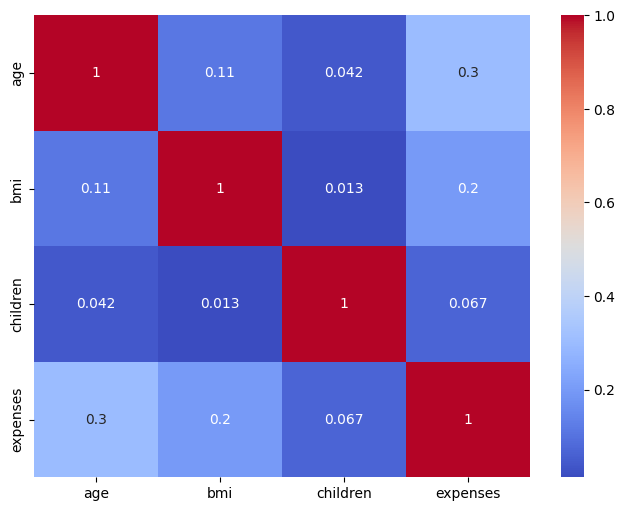

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')
plt.show()

In [ ]:
X = df.drop('expenses', axis=1)
y = df['expenses']
print("Input Features:")
print(X.columns
print("Output Feature:")
print(y.name)

Input Features:
Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region'], dtype='object')
Output Feature:
expenses


In [ ]:
df_encoded = pd.get_dummies(
    df,
    columns=['sex', 'smoker', 'region']
)
print(df_encoded.head())

   age   bmi  children  expenses  sex_female  sex_male  smoker_no  smoker_yes  \
0   19  27.9         0  16884.92        True     False      False        True   
1   18  33.8         1   1725.55       False      True       True       False   
2   28  33.0         3   4449.46       False      True       True       False   
3   33  22.7         0  21984.47       False      True       True       False   
4   32  28.9         0   3866.86       False      True       True       False   

   region_northeast  region_northwest  region_southeast  region_southwest  
0             False             False             False              True  
1             False             False              True             False  
2             False             False              True             False  
3             False              True             False             False  
4             False              True             False             False  


In [ ]:
X = df_encoded.drop('expenses', axis=1)
X_scaled = (X - X.mean()) / X.std()
print(X_scaled.head())

        age       bmi  children  sex_female  sex_male  smoker_no  smoker_yes  \
0 -1.439879 -0.453315 -0.908894    1.009393 -1.009393  -1.968924    1.968924   
1 -1.511082  0.513793 -0.079412   -0.989953  0.989953   0.507512   -0.507512   
2 -0.799051  0.382660  1.579552   -0.989953  0.989953   0.507512   -0.507512   
3 -0.443036 -1.305681 -0.908894   -0.989953  0.989953   0.507512   -0.507512   
4 -0.514239 -0.289398 -0.908894   -0.989953  0.989953   0.507512   -0.507512   

   region_northeast  region_northwest  region_southeast  region_southwest  
0         -0.565334         -0.565334         -0.611409          1.763949  
1         -0.565334         -0.565334          1.634343         -0.566486  
2         -0.565334         -0.565334          1.634343         -0.566486  
3         -0.565334          1.767542         -0.611409         -0.566486  
4         -0.565334          1.767542         -0.611409         -0.566486  


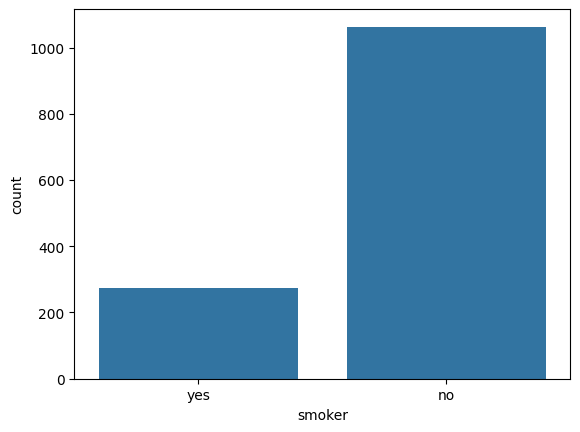

In [ ]:
sns.countplot(x='smoker', data=df)
plt.show()

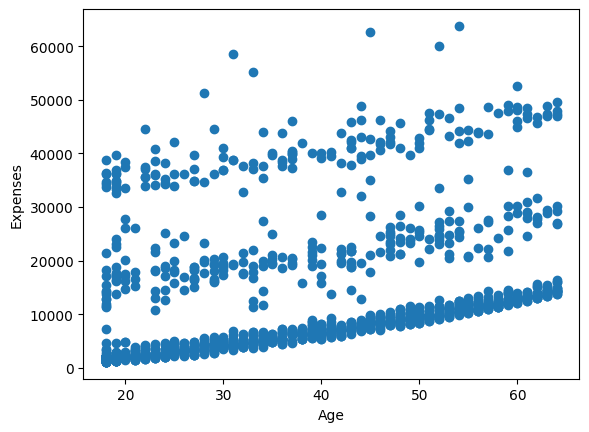

In [ ]:
plt.scatter(df['age'], df['expenses'])
plt.xlabel("Age")
plt.ylabel("Expenses")
plt.show()

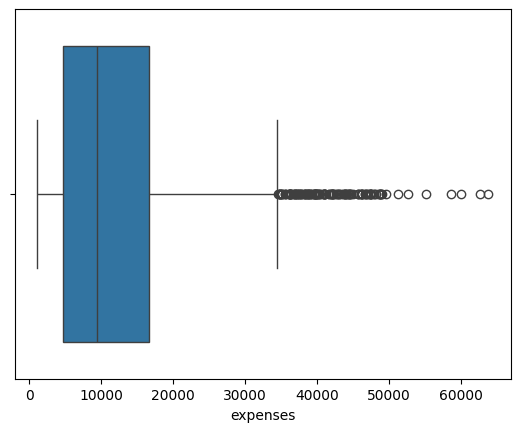

In [ ]:
sns.boxplot(x=df['expenses'])
plt.show()

In [ ]:
X = df.drop('expenses', axis=1)
y = df['expenses']

print(X.head())
print(y.head())

   age     sex   bmi  children smoker     region
0   19  female  27.9         0    yes  southwest
1   18    male  33.8         1     no  southeast
2   28    male  33.0         3     no  southeast
3   33    male  22.7         0     no  northwest
4   32    male  28.9         0     no  northwest
0    16884.92
1     1725.55
2     4449.46
3    21984.47
4     3866.86
Name: expenses, dtype: float64


In [ ]:
print(df_encoded.shape)
print(df_encoded.columns)

(1337, 12)
Index(['age', 'bmi', 'children', 'expenses', 'sex_female', 'sex_male',
       'smoker_no', 'smoker_yes', 'region_northeast', 'region_northwest',
       'region_southeast', 'region_southwest'],
      dtype='object')
